### Nomenclature 
NN      Neural Network  
PINN       Physics-Informed Neural Network

# Tasks

### Implementation 
1. Import and prepare data
    1. Generate with existing data generator
    2. Visualize
    3. Prepare data for NN training  
    Implement all steps except of step 3
<br><br>

2. Set up Neural Network
    1. Implement NN architecture
    2. Implement Forward Function 
<br><br>
  
3. Write Training
    1. Define and Implement the Data Loss Function
    2. Implement the execution Function
<br><br>

___
### Execution 

4. Verification: Execute Training and Visualize 
    1. Execute the training for the following set of (hyper)parameters.  
    Plot the loss evolution during training and the final prediction of the model (after training).
    Compare the final predictions to the true solution of the trajectory. 
        
        - Use default parameters for the data generation
        - Use 20 points (linearly spaced in time) from the generated data for the train_ds.  
            Use the remaining points for the test_ds
        - Use a neural network with one hidden layer with each having 64 neurons. 
        - learning rate $\eta = 0.01$
        - training epochs $n_\text{epochs} = 300$
<br><br>

5. Hyperameter   
    We could now change all hyperparameters of the model (learning rate, model depth, model width, ...) and identify the best possible configuration for the given task. 
    Even though this is not the goal of this lab course, it is nice to get a rough impression of the effect of a hyperparameter. 
    Therefore, we now tune the learning rate:  
    1. Implement a loop over the following list of learning rates. 
    In each loop we train the neural network using the configuration from task 4 (except of the learning rate). 
    Save all the loss evolutions and the final model predictions.

        Learning rates = [1, 1e-1, 1e-2, 1e-3, 1e-4]

    2. Compare the loss evolutions and the final predictions in two plots.  
    Additionally, plot the true solution of the trajectory to compare the final predictions. 
    
    3. Which learning rate yields the best results?  
    Explain why. 

___
### Implementation 

6. Implement the PINN
    1. Implement the function `compute_physics_informed_loss`
    2. Include the Physics Loss in `compute_total_loss`
    3. Generate Collocation Points that are used to train the physics loss  

            Todo: Implement pipeline for collocation points and link to this task 
                Make default 100
            Todo: Enable the user to activate and deactivate the physics loss from outside. 

___
### Execution 

7. Compare PINN to regular NN.  
    Goal of this task is to identify the difference in performance between a regular NN and a PINN. 
    For that, we change the number of training samples we use to train the data loss. 
    We will use the following three training data sets:  
    
    - 20 equally spaced points over the entire data set.
    - 10 equally space points over the first half of the data. 
    - 2 points using the first and last point of the data set. 

    1. For each of these data sets, execute one training of a PINN (with phsics loss) and one training of regular NN (without physics loss) using the parameter configuration from task 4 (except the training data points). 
    Moreover, use the default value of 100 collocation points for the physics loss. 
    Store the loss evolution and the final model performance of each run. 
    Execute this study by looping over all configurations, which means the study should be executed in one run. 
    
            Todo: Get help with setting up the task

    2. Create 3 plots, one for each set of training data, in which you compare the loss evolution and the final model prediction of the PINN to the regular NN. 


8. Vary Collocation points.  
    1. Now we want to identify the effect of the collocation points when training a PINN.  
    For that we simply vary the number of collocation points using the following setup:

    - 5 linearly spaced over time
    - 20 linearly spaced over time
    - 50 linearly spaced over time
    - 100 linearly spaced over time

    2. Plot and compare the loss evolution and final prediction of all four configurations. 

    3. What can you see, and how can you explain the behavior?

# Physics background

This PINN aims to learn and predict the trajectory of a projectile slowed down by a drag force.

The magnitude of the force depends on the following parameters:
1. $\rho$ the Air density $(\text{kg}/\text{m}^3)$, 
2. $C_d$ the drag coefficient, 
3. $A$ the Cross-sectional area $(\text{m}^2)$

All these parameters can be summarized to one coefficient:
- $\mu = 0.5 * \rho * C_d * A$

Moreover, the drag force depends on the square of the projectile's speed:
- $F = \mu * v * |v|$ 
where $F$ can be split up in $x$-and $y$-components:
- $F_x = \mu * \frac{dx}{dt} * |v|$ and 
- $F_y = \mu * \frac{dy}{dt} * |v|$

The resulting differential equations describe the path of the projectile:
- $\frac{d^2x}{dt^2} = F_x/m$
- $\frac{d^2y}{dt^2} = F_y/m - g$ 

Where $m$ is the Mass of the projectile $(\text{kg})$ and $g$ the earths gravitational acceleration. 

# Library import

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import copy

from physics_data_generator import ProjectileDataGenerator, PhysicalSystem
from Animator import AnimationGenerator

# Data generation

In [2]:
# Use existing code to generate training data
physical_system = PhysicalSystem() #PhysicalSystem(drag_coeff=0.0, v_0=torch.tensor([5, 5]))
data_generator = ProjectileDataGenerator(physical_system)

# Generate training data
data_generator.integrate()

# Get training data
time = data_generator.time
position = data_generator.position
velocity = data_generator.velocity
acceleration = data_generator.acceleration

# Get the physical system parameters
g = physical_system.g
Cd = physical_system.drag_coeff
A = physical_system.cross_area
m = physical_system.mass
mu = physical_system.coeff

Text(0, 0.5, 'Vertical Distance (m)')

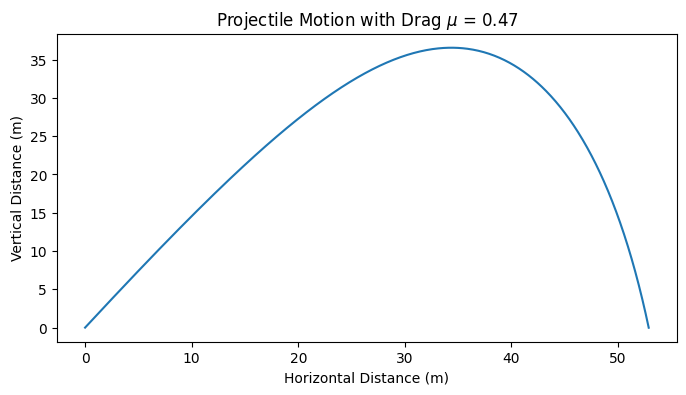

In [3]:
# Todo: Create a plot of the simulated data
# Plot the trajectory of the projectile

plt.figure(figsize=(8, 4))
plt.plot(position[:, 0], position[:, 1])
plt.title(rf"Projectile Motion with Drag $\mu$ = {physical_system.drag_coeff:.2f}")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")

# Data preparation

In [4]:
def create_training_data(
        time_vals, 
        position_vals, 
        num_t_train = 10,  
        max_t_train = 2,
        min_t_train = 0,
        num_t_col = 100,
    ):
    """
    Create training data for training procedure.

    This function generates training data using a subset
    of time values ('time_vals' tensor) and corresponding 
    x- and y-components ('position_vals' tensor).
    Therefore the following steps need to be done:
    

    Step 1: Data Point Selection
            Select evenly spaced values from the 'time_vals' and 'position_vals' arrays:

            - Create a tensor 'all_idx' containing indices between 0 
              and time_vals[-1]*100 to select data points.
            - Create a tensor 'idx_train' containing 'num_t_train'evenly spaced indices 
              between 0 and max_t_train*100 to select data points.
            - Generate a mask with booleans of len(all_idx) that gives False statements for entries
              that are both in 'all_idx' and in 'idx_train'.
            - Build a tensor 'idx_test' by applying the mask on 'all_idx'.
            - Ensure that the data type of all idx tensors are integer.

    Step 2: Training Data Creation
            - Define 't_train', 'x_train', and 'y_train' tensors by selecting index values 'idx_train' 
              from 'time_vals' and 'position_vals'.
            - We don't want to make changes to the original data therefore use '.clone().detach()'.
            - Format the tensor size as 'torch.Size([num_t_train, 1])' by applying the .unsqueeze(1) method.
        
    Step 3: Testing Data Creation
            Repeat the procedure of step to by selecting index values 'idx_test'.
    
    Step 4: Colocation points
            Build 't_col', a tensor that includes 'num_t_col' evenly spaced Values 
            between 0 and the last value in 'time_vals'.

    Step 5: Dataset Creation
            Create datasets train_ds and test_ds by using dictionaries 
            containing "inputs", "targets_x", "targets_y" and "t_col" entries.
        
    Step 6:  Return the created datasets.
    
    Parameters
    ----------
    time_vals : torch.Tensor
        A tensor containing time values.
    position_vals : torch.Tensor
        A tensor containing x- and y-components of the displacement vector.
    num_t_train : int, optional
        The number of data points to select from the provided time. Default is 10.
    max_t_train : float, optional
        The maximum time value to include in the training data. Default is 2.
    min_t_train : float, optional
        The minimum time value to include in the training data. Default is 0.
    num_t_col : int, optional
        The number of evenly spaced time values to generate in 't_col'. Default is 100.
        
    Returns
    -------
    Dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries for training data.
    Dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries for testing data.
    """
    
    # Step 1: Create a tensors of indices that correspond to the selected time values.
    all_idx = torch.arange(0, time_vals[-1]*100, dtype=torch.int)
    idx_train = torch.linspace(min_t_train*100, max_t_train*100, num_t_train, dtype=torch.int)
    mask = ~torch.isin(all_idx, idx_train)
    idx_test = all_idx[mask]
    
    # Step 2: - Get t_train, x_train and y_train by selecting values from the provided data.
    #         - Generate a t_col tensor with evenly spaced time Values in t_ime_vals and num_t_col steps
    t_train = time_vals[idx_train].clone().detach().to(torch.float32).unsqueeze(1)
    x_train = position_vals[idx_train, 0].clone().detach().unsqueeze(1)
    y_train = position_vals[idx_train, 1].clone().detach().unsqueeze(1)

    
    # Step 3: Get t_test, x_test, y_test from the provided data
    t_test = time_vals[idx_test].clone().detach().to(torch.float32).unsqueeze(1)
    x_test = position_vals[idx_test, 0].clone().detach().unsqueeze(1)
    y_test = position_vals[idx_test, 1].clone().detach().unsqueeze(1)

    # Step 4: Build  t_col with evnely spaced values out of time_vals
    t_col = torch.linspace(0, time_vals[-1], num_t_col).unsqueeze(1)
    
    # Step 5: Create datasets train_ds and test_ds by using dictionaries 
    train_ds = {"inputs": t_train, "targets_x": x_train,"targets_y": y_train, "t_col": t_col}
    test_ds = {"inputs": t_test, "targets_x": x_test, "targets_y": y_test, "t_col": t_col}

    # Step 6: return datasets
    return train_ds, test_ds


# Create PINN model

In [5]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of torch.nn.Module defines the architecture of the PINN model. 
    It is designed to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    Step 1: Model Initialization
        - Initialize the PINN model as a subclass of nn.Module.

    Step 2: Constructor Definition
        - Build a constructor to configure the model's architecture.
        - Utilize the nn.Linear class from the PyTorch library for defining layers and connections.

    Step 3: Forward Pass Mechanism
        - Define the forward pass mechanism for the model, where input data flows through the layers
          to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time data.
        - One hidden fully connected layer fc2 with 64 neurons.
        - Output layer fc_x for predicting the x-coordinate.
        - Output layer fc_y for predicting the y-coordinate.
        
        Parameters
        ----------
        None
            
        Attributes
        ----------
        fc1 : nn.Linear
            First fully connected layer.
        fc2 : nn.Linear
            Second fully connected layer.
        fc_x : nn.Linear
            Output layer for x-coordinate prediction.
        fc_y : nn.Linear
            Output layer for y-coordinate prediction.
        
        Returns
        -------
        None
        
        """
        super(PINN, self).__init__()
        
        # Step 2: Configure model architecture as described earlier
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc_x = nn.Linear(64, 1)
        self.fc_y = nn.Linear(64, 1)
    
    def forward(self, t):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data t is processed through the layers to produce predicted
        outputs for both x-coordinate (x_output) and y-coordinate (y_output).
        The following steps are necessary:
        
    1. First Fully Connected Layer with GELU Activation:
        - Pass the input tensor 't' through the 'fc1' linear layer.
        - Apply the GELU activation function 'torch.nn.functional.gelu(...)' to the output.

    2. Second Fully Connected Layer with GELU Activation:
        - Pass the output of the previous step ('t') through the 'fc2' linear layer.
        - Apply the GELU activation function to the output.

    3. Output Layer for Predicted Coordinates:
        - Compute the predicted x-coordinate by passing the transformed tensor 't' 
          through the 'fc_x' layer.
        - Compute the predicted y-coordinate by passing the same transformed tensor 't' 
          through the 'fc_y' layer.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted x and y coordinates.
        """

        # Step 1: Apply the first fully connected layer with GELU activation
        t = torch.nn.functional.gelu(self.fc1(t))
        
        # Step 2: Apply the second fully connected layer with GELU activation
        t = torch.nn.functional.gelu(self.fc2(t))
        
        # Step 3: Produce predicted x and y coordinates using output layers
        x_output = self.fc_x(t)  # Predicted x-coordinate
        y_output = self.fc_y(t)  # Predicted y-coordinate
        
        return x_output, y_output


# Physicis informed loss

In [6]:
def compute_physics_informed_loss(model, dataset: dict):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the underlying physics
    principles into the PINN. The following steps are involved:
    
    Step 1: Data Preparation
        - Unpack 't_col' from the dataset and enable gradient computation.

    Step 2: Model Prediction
        - Predict x and y values by calling the neural network model on 't_col'.

    Step 3: Gradient Computation
        - Compute the first gradients 'dx_dt' and 'dy_dt', and second gradients 
        'd2x_dt2' and 'd2y_dt2', using the 'torch.autograd.grad' command.
        - On the first parameter of the 'torch.autograd.grad', first apply the 'torch.sum' method.

    Step 4: Velocity and Drag Calculation
        - Calculate the speed 'v' using the Euclidean norm of the vector [dx_dt, dy_dt].
        - Define the x and y components of the drag force.

    Step 5: Loss Calculation
        - Calculate the mean squared error loss for both the x and y components using
        the 'nn.MSELoss()' class.
        (see [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))

    Step 6: Loss Combination
        - Return the combined physics-informed loss as the sum of 'loss_x' and 'loss_y'.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x", "targets_y" and "t_col" entries.
        
    Returns
    -------
    torch.Tensor
        The combined (x and y) physics-informed loss.
    """
    # Step 1: Unpack and Enable gradient computation for t_col
    t_col = dataset["t_col"]
    t_col.requires_grad = True
    
    # Step 2: Predict x and y values using the neural network model
    x_pred, y_pred = model(t_col)
    
    # Step 3: Compute first and second gradients
    dx_dt = torch.autograd.grad(torch.sum(x_pred), t_col, create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(torch.sum(dx_dt), t_col, create_graph=True)[0]
    
    dy_dt = torch.autograd.grad(torch.sum(y_pred), t_col, create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(torch.sum(dy_dt), t_col, create_graph=True)[0]
    
    # Step 4: Calculate the speed v using the Euclidean norm 
    #         and define x and y component of the drag force.
    v = torch.sqrt(dx_dt ** 2 + dy_dt ** 2)
    Fx = -mu * v * dx_dt
    Fy = -mu * v * dy_dt
    
    # Step 5: Compute the mean squared error loss 
    #         and store by defining variables called 'loss_x' and 'loss_y'.
    mse_loss = nn.MSELoss()
    loss_x = mse_loss(d2x_dt2, Fx / m)
    loss_y = mse_loss(d2y_dt2, ((Fy / m) - g))

    # Step 6: Return the combined (x and y) physics-informed loss
    return loss_x + loss_y


# Data loss

In [7]:
def compute_data_loss(model, dataset: dict):
    """
    Define the data loss for the PINN model.
    
    This function calculates the loss based on the discrepancy between the predicted
    and actual data points, typically used for data-driven training of the PINN. The
    following steps are involved:
    

    Step 1: Model Prediction
        - Compute the predicted x and y values by calling the neural network model.

    Step 2: Loss Calculation
        - Calculate the mean squared error loss for both the x and y components using
        the 'nn.MSELoss()' class.
        (see [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))

    Step 3: Loss Combination
        - Return the combined data loss as the sum of 'loss_x' and 'loss_y'.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x", "targets_y" and "t_col" entries.
        
    Returns
    -------
    torch.Tensor
        The combined data loss based on predicted vs. actual data.
    """
    # Step 1: Compute predicted x and y values using the neural network model
    x_pred, y_pred = model(dataset["inputs"])
    
    # Step 2: Calculate mean squared error loss
    mse_loss = nn.MSELoss()
    loss_x = mse_loss(x_pred, dataset["targets_x"])
    loss_y = mse_loss(y_pred, dataset["targets_y"])
    
    # Step 3: Return the combined (x and y) data loss
    return loss_x + loss_y

# Total Loss

In [8]:
import torch

def compute_total_loss(model, dataset: dict, activate_physics=False):
    """
    Define the total loss for the physics-informed neural network.

    This function computes the total loss for the PINN model by combining two
    different components: data loss and physics-informed loss.
    The following steps are involved:

    Step 1: Data Loss Calculation
        - Determine the data loss using the 'compute_data_loss()' function.

    Step 2: Physics-Informed Loss Calculation (if activated)
        - If 'activate_physics' is set to True, calculate the physics-informed loss
        using the 'compute_physics_informed_loss()' function.

    Step 3: Total Loss Combination
        - Return the combined total loss as the sum of 'data_loss' and 'physics_loss' (if activated).

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries.
    activate_physics : bool, optional
        Whether to activate the physics-informed loss. Default is False.

    Returns
    -------
    torch.Tensor
        The combined total loss considering data and physics constraints.
    """
    # Calculate the data loss
    data_loss = compute_data_loss(model, dataset)

    # Calculate the physics-informed loss if 'activate_physics' is True
    if activate_physics:
        physics_loss = compute_physics_informed_loss(model, dataset)
    else:
        physics_loss = 0.0  # Set physics loss to zero if not activated

    # Combine data loss and physics loss (if activated) to get the total loss
    total_loss = data_loss + physics_loss

    return total_loss


# Executive function

In [26]:
def execute(
        model,
        train_ds: dict,
        test_ds: dict,
        lr = 0.005, 
        num_epochs = 1000,
        activate_physics = False,
    ):
    """
    Execute the training procedure for a physics-informed neural network model.

    This function trains the model using specified hyperparameters and returns relevant data.
    The process involves the following steps:
    
    Step 1: Optimizer Initialization
            The optimizer is used to update the model's parameters during training. Therefore:
            - Initialize the optimizer, Adam with the model parameters.
            - Configure it with a specified learning rate (lr).
        
    Step 2: Lists Initialization
            In order to store the values of the models loss and prediction during the training process:
            - Initialize the lists train_loss_evolution, test_loss_evolution and predictions_list. 

    Step 3: Training Loop Setup
            Set up a training loop that will run for a specified number of epochs ('num_epochs'). 
            An epoch is one complete pass through the entire training dataset.

    Inside the training loop:

        Step 4: Gradient Reset
                Reset the gradient of the optimizer to zero by invoking 'optimizer.zero_grad()' 
                in preparation for a fresh gradient computation.

        Step 5: Loss Calculation
                Calculate the 'train_loss' and 'test_loss' using the 'compute_total_loss' function.
                Make sure,
                - the 'train_loss' takes the 'activate_physics' information is taken from the methods parameters
                - the 'test_loss' is calculated with 'activate_physics' set to False. 

        Step 6: Training Step
                - Calculate the gradients of the model's parameters with respect to the total loss 
                  using 'loss.backward()'. 
                - Then call 'optimizer.step()' in order to update the model parameters 
                  based on the calculated gradients beforehand. 

        Step 7: Loss Tracking
                - For later analysis, append the current train and test loss values to the appropriated lists.
                - If desired, every 20 epochs, the code prints the current epoch number 
                  and the value of the loss.

        Step 8: Model Predictions Storage
                - Compute a model prediction using the 'test_ds'.
                - Store the current model predictions in the 'predictions_list'.

    Step 9: Data Return
            Once the training loop is completed, return the lists you have initialized in Step 2.

    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to be trained and evaluated.
    train_ds : dict
        A dictionary containing training data, including inputs and targets.
    test_ds : dict
        A dictionary containing test data, including inputs and targets.
    lr : float, optional
        Learning rate for the optimizer. Default is 0.005.
    num_epochs : int, optional
        Number of training epochs. Default is 1000.

    Returns
    -------
    list
        A list containing train loss values during training.
    list
        A list containing test loss values during training
    list
        A list of model predictions on the test data at different epochs.  
    """    
    
    # Step 1: Initialize optimizer 
    optimizer = optim.Adam(model.parameters(), lr=lr,)  # Include weight_decay in the optimizer
    
    # Step 2: Initialize the lists train_loss_evolution, test_loss_evolution, predictions_list.
    train_loss_evolution = []
    test_loss_evolution = []
    predictions_list = []
    
    # Step 3: Set up the training loop
    for epoch in range(num_epochs):
        
        # Step 4: Reset the optimizers gradient
        optimizer.zero_grad()
        
        # Step 5: Compute the total loss for the training and the test data.
        train_loss = compute_total_loss(model, train_ds, activate_physics=activate_physics)
        test_loss = compute_total_loss(model, test_ds, activate_physics=False)
        
        
        # Step 6 calculate the gradients using backpropagation
        train_loss.backward()
        optimizer.step()


        # Step 7: Store the current loss value in the loss history and print every 100th epoch the Loss.
        train_loss_evolution.append(float(train_loss))
        test_loss_evolution.append(float(test_loss))
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Train Loss: {train_loss.item()}, Test Loss: {test_loss.item()}")
            
        # Step 8: Store the current model prediction in the respective list.
        predictions = model(test_ds['inputs'])
        predictions_list.append(predictions)
            
    
    # Step 9: return loss_evolution, num_epochs
    return train_loss_evolution, test_loss_evolution, predictions_list

# Execute

In [27]:
# Initialize the model by calling the PINN() class created earlier.
model = PINN()

train_ds, test_ds = create_training_data(
    time_vals=time, 
    position_vals=position, 
    num_t_train=10,
    min_t_train=0.0,
    max_t_train=time[-1]/2,
    num_t_col=50
)
print("train_ds_t", train_ds["inputs"][0])
print("test_ds_t", test_ds["inputs"][0])
train_loss_evolution, test_loss_evolution, predictions_list = execute(
    model,
    test_ds=test_ds,
    train_ds=train_ds,
    num_epochs=230,
    activate_physics=True
)

train_ds_t tensor([0.])
test_ds_t tensor([0.0100])
Epoch 0/230, Train Loss: 1688.7515869140625, Test Loss: 2187.285400390625
Epoch 20/230, Train Loss: 548.891357421875, Test Loss: 503.09716796875
Epoch 40/230, Train Loss: 178.46127319335938, Test Loss: 401.0301513671875
Epoch 60/230, Train Loss: 96.34877014160156, Test Loss: 278.1152648925781
Epoch 80/230, Train Loss: 62.08864212036133, Test Loss: 196.7799072265625
Epoch 100/230, Train Loss: 42.57924270629883, Test Loss: 94.56299591064453
Epoch 120/230, Train Loss: 21.064098358154297, Test Loss: 15.654831886291504
Epoch 140/230, Train Loss: 3.688173294067383, Test Loss: 1.4339585304260254
Epoch 160/230, Train Loss: 0.77546226978302, Test Loss: 0.1703023761510849
Epoch 180/230, Train Loss: 0.28732380270957947, Test Loss: 0.023055167868733406
Epoch 200/230, Train Loss: 0.16993872821331024, Test Loss: 0.02516460046172142
Epoch 220/230, Train Loss: 0.11275579780340195, Test Loss: 0.01848541758954525


# Network prediction


In [28]:
# Generate Network prediction of the trained model
t = time.clone().detach().to(torch.float32).unsqueeze(1)
x_pred, y_pred = model(t)

# Plot

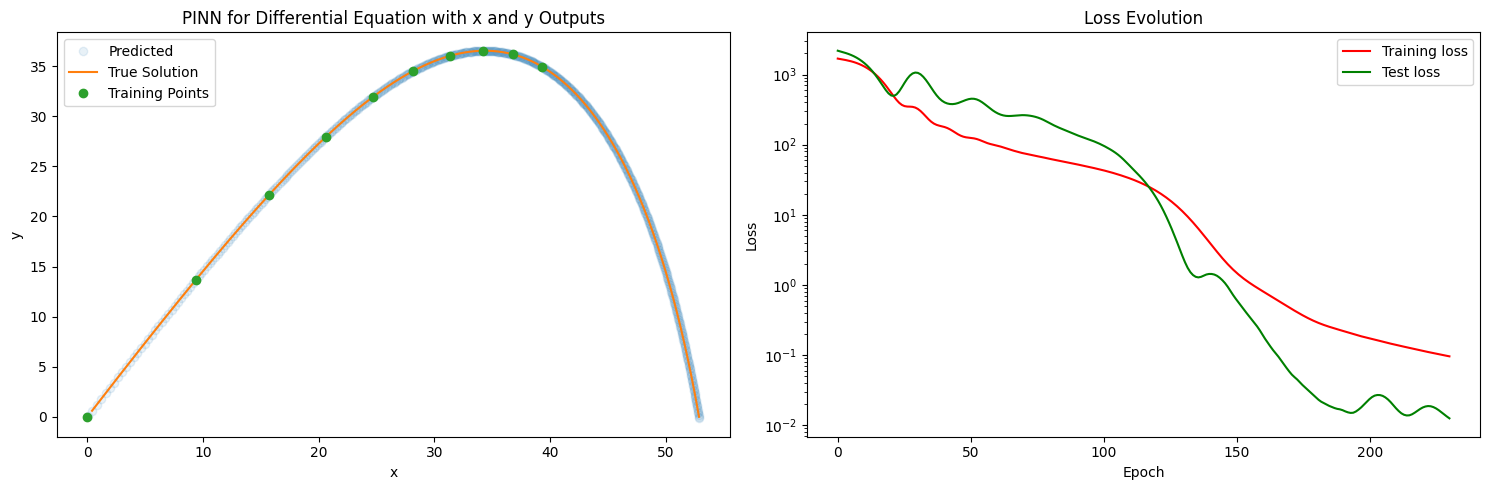

In [29]:
# Create a figure with subplots
fig, axs = plt.subplots(1, 2, figsize=(15,5))  # 1 row, 2 columns of subplots

# Plot data on the first subplot
axs[0].plot(x_pred.detach().numpy(), y_pred.detach().numpy(), 'o', alpha=0.1, label='Predicted')
axs[0].plot(test_ds["targets_x"], test_ds["targets_y"], label='True Solution')
axs[0].plot(train_ds["targets_x"].detach().numpy(), train_ds["targets_y"].detach().numpy(), 'o', label='Training Points')
axs[0].legend()
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('PINN for Differential Equation with x and y Outputs')
# axs[0].set_ylim(-20, 60)
# axs[0].set_xlim(-20, 60)

# Plot loss evolution on the second subplot

axs[1].plot(np.linspace(0, len(train_loss_evolution), len(train_loss_evolution)), train_loss_evolution, c='r', label='Training loss')
axs[1].plot(np.linspace(0, len(test_loss_evolution), len(test_loss_evolution)), test_loss_evolution, c='g', label='Test loss')
axs[1].legend()
axs[1].set_title('Loss Evolution')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_yscale('log')  # Set y-axis to logarithmic scale
# Adjust layout for subplots
plt.tight_layout()

# Show the plot
plt.show()


# Animation

In [ ]:
# Example usage:
animator = AnimationGenerator(train_loss_evolution, 
                              test_loss_evolution, 
                              predictions_list, 
                              train_ds, 
                              test_ds)
animator.create_animation('lets_see', frames=len(train_loss_evolution), fps=30)

# Evaluation Task

In [ ]:
# Initialize an empty dictionary to store data
data_dict = {}
pred_dict = {}
# Create a Looplist, with all important information for the data Generatrion (num_t_train, min_t_train, max_t_train)
Looplist = [(20, 0, time[-1]), (10, 0, time[-1]/2), (2, 0, time[-1])]

# Initialize test_ds before the loop so it can be used after the loop.
test_ds = None

for i, (num_t_train, min_t_train, max_t_train) in enumerate(Looplist):

    train_ds, test_ds = create_training_data(
        time_vals=time,
        position_vals=position,
        num_t_train=num_t_train,
        max_t_train=max_t_train,
        min_t_train=min_t_train,
        num_t_col=100
    )


    key = f"data_{i}"
    data_dict[key] = {"train_ds": train_ds, "test_ds": test_ds}

loop_list = [("data_0", True),  ("data_0", False), ("data_1", True), ("data_1", False), ("data_2", True), ("data_2", False)]

In [ ]:

for  i, (data, physics) in enumerate(loop_list):
    # Initialize the model by calling the PINN() class created earlier.
    model = PINN()

    # print(f"data_{i} targets_y", data_dict[data]["targets_y"])

    # Execute the training for the given data_set
    train_loss_evolution, test_loss_evolution, predictions_list = execute(
        model,
        train_ds=data_dict[data]['train_ds'],
        test_ds=data_dict[data]['test_ds'],
        num_epochs=500,
        weight_decay=1e-6,
        activate_physics=physics
    )
    print(data_dict[data]["train_ds"]['inputs'].shape)
    # Generate the model prediction
    
    t = time.clone().detach().to(torch.float32).unsqueeze(1)#test_ds["inputs"]
    x_pred, y_pred = model(t)
    
    # Create a new sub_dict with all data that contains relevant for the plots
    data_value = {
        "train_loss_evolution": train_loss_evolution,
        "test_loss_evolution": test_loss_evolution,
        "x_pred": x_pred.detach().numpy(),
        "y_pred": y_pred.detach().numpy(),
        "targets_x": data_dict[data]["train_ds"]["targets_x"],
        "targets_y": data_dict[data]["train_ds"]["targets_y"]
    }
    # Add the sub-dictionary to data_dict keys (data_1,...)
    print(f"data_{i}")
    pred_dict[f"data_{i}"] = data_value



In [ ]:
for data, sub_dict in pred_dict.items():
    # Create a figure with subplots
    fig, axs = plt.subplots(1, 2, figsize=(15,5))  # 1 row, 2 columns of subplots

    # Plot data on the first subplot
    axs[0].plot(sub_dict["x_pred"], sub_dict["y_pred"], 'o', alpha=0.1, label='Predicted')
    axs[0].plot(test_ds["targets_x"], test_ds["targets_y"], label='True Solution')
    axs[0].plot(sub_dict["targets_x"].detach().numpy(), sub_dict["targets_y"].detach().numpy(), 'o', label='Training Points')
    axs[0].legend()
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    axs[0].set_title(f'PINN for Differential Equation with x and y Outputs')
    # axs[0].set_ylim(-20, 60)
    # axs[0].set_xlim(-20, 60)

    # Plot loss evolution on the second subplot

    axs[1].plot(np.linspace(0, len(sub_dict["train_loss_evolution"]), len(sub_dict["train_loss_evolution"])), sub_dict["train_loss_evolution"], c='r', label='Training loss')
    axs[1].plot(np.linspace(0, len(sub_dict["test_loss_evolution"]), len(sub_dict["test_loss_evolution"])), sub_dict["test_loss_evolution"], c='g', label='Test loss')
    axs[1].legend()
    axs[1].set_title('Loss Evolution')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_yscale('log')  # Set y-axis to logarithmic scale
    # Adjust layout for subplots
    plt.tight_layout()

    # Save the plot as a PNG file
    plt.savefig(f"data_{i}")

    # Show the plot
    plt.show()
